In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import scipy.stats as stats


from sim.sim_plots import plotTermStructure, plotYield
from pricing.pricer import PricerClass
from mpl_bsic import apply_bsic_style, export_figure

In [40]:
def plotStressScenario(baseParams, stressEffects, 
                       baseFactors, stressFactors, 
                       showStressed = True, subplotTitles = None, overallTitle = None, figsize = (20,3), rect = [0, 0, 1, 1.05],
                       export = False, exportName = None):
    stressParams = {key: baseParams[key] + stressEffects[key] for key in baseParams}
    stressPricer = PricerClass(**stressParams)
    basePricer = PricerClass(**baseParams)
    
    
    fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = figsize, sharey=False)
    ax[0].plot(MATURITIES, basePricer.termStructure(MATURITIES, baseFactors), color = 'blue', label = 'Base')
    if showStressed:
        ax[0].plot(MATURITIES, stressPricer.termStructure(MATURITIES, stressFactors), color = 'red', label = 'Stress')
    if subplotTitles is not None:
        ax[0].set_title(subplotTitles[0])
    else:
        ax[0].set_title('Model term structure of yields')
    ax[0].set_xlabel('Tenor')
    ax[0].set_ylabel('ZCB yield')
    ax[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f'{y:.2%}'))
    ax[0].grid(True)
    ax[0].legend()
    
    ax[1].plot(MATURITIES, basePricer.forwardTermStructure(deltaTau = 1, maturities= MATURITIES, factors= baseFactors), color = 'blue', label = 'Base')
    if showStressed:
        ax[1].plot(MATURITIES, stressPricer.forwardTermStructure(deltaTau = 1, maturities= MATURITIES, factors= stressFactors), color = 'red', label = 'Stress')
    if subplotTitles is not None:
        ax[1].set_title(subplotTitles[1])
    else:
        ax[1].set_title('Model term structure of 1-year-forward rates')
    ax[1].set_xlabel('Tenor (years)')
    ax[1].set_ylabel('1-year-forward Rate')
    ax[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f'{y:.2%}'))
    ax[1].grid(True)
    ax[1].legend()
    if overallTitle is not None:
        plt.suptitle(overallTitle)
    apply_bsic_style(fig, ax)
    plt.tight_layout(rect=rect)  # leave top 8% for suptitle
    plt.show()
    if export:
        export_figure(fig = fig, filename = exportName)
        plt.savefig(f'{exportName}.png', dpi = 300)

In [41]:
MATURITIES = np.array([0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 30, 40, 50])
baseParams = dict(
    alpha_r = 1.0547, alpha_m = 0.6358, alpha_l = 0.0165,
    sigma_m = 109.2/10000, sigma_l = 96.4/10000,
    rho = 0.2,
    mu = 10.055/100,
)

baseFactors = [0.03, 0.04, 0.05]

fonts already added so will not add again


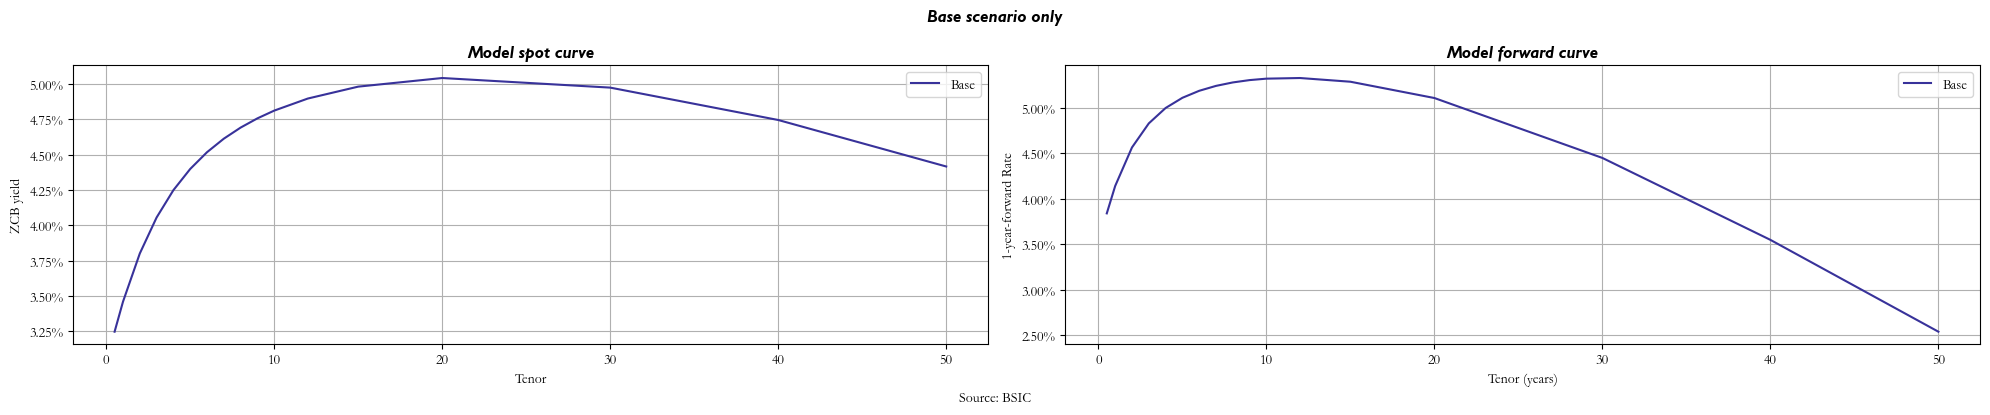

<Figure size 640x480 with 0 Axes>

In [44]:
stressEffects = {key: 0 for key in baseParams.keys()}
stressFactors = [x for x in baseFactors]

plotStressScenario(baseParams, stressEffects, baseFactors, stressFactors, 
                   showStressed = False, 
                   subplotTitles = ['Model spot curve', 'Model forward curve'], 
                   overallTitle='Base scenario only', 
                   figsize = (20, 4), 
                   rect = [0, 0, 1, 1.005],
                   export = True, exportName = 'pricing/pricer test pictures/base_scenario')

### 1. Plots with different $(r_t, m_t, l_t)$

#### 1.1. Stress $r_t$

fonts already added so will not add again


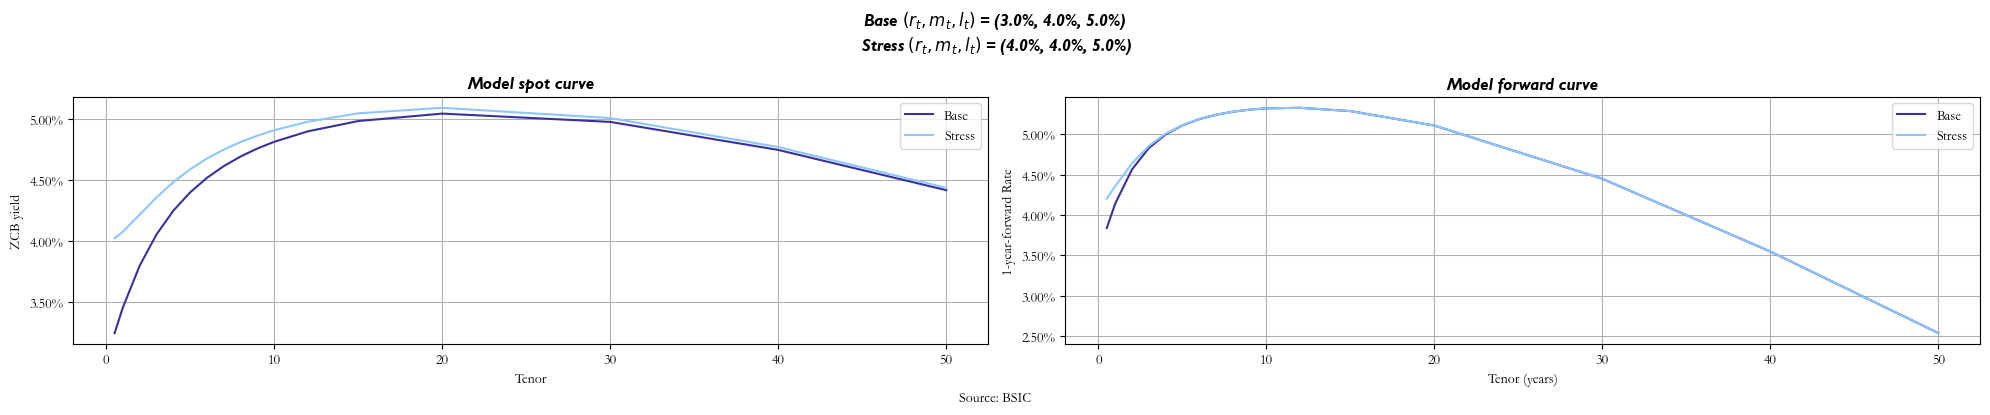

<Figure size 640x480 with 0 Axes>

In [45]:
stressEffects = {key: 0 for key in baseParams.keys()}
stressFactors = [baseFactors[0] + 0.01,
                 baseFactors[1] + 0.0,
                 baseFactors[2] + 0.0]

plotStressScenario(baseParams, stressEffects, baseFactors, stressFactors, 
                   showStressed= True, 
                   subplotTitles = ['Model spot curve', 'Model forward curve'], 
                   overallTitle=f'Base $(r_t, m_t, l_t)$ = ({baseFactors[0]:.1%}, {baseFactors[1]:.1%}, {baseFactors[2]:.1%}) \n Stress $(r_t, m_t, l_t)$ = ({stressFactors[0]:.1%}, {stressFactors[1]:.1%}, {stressFactors[2]:.1%})', 
                   figsize = (20, 4), 
                   rect = [0, 0, 1, 1.005],
                   export = True, exportName = 'pricing/pricer test pictures/shift in r_t up')

#### 1.2. Stress $m_t$

fonts already added so will not add again


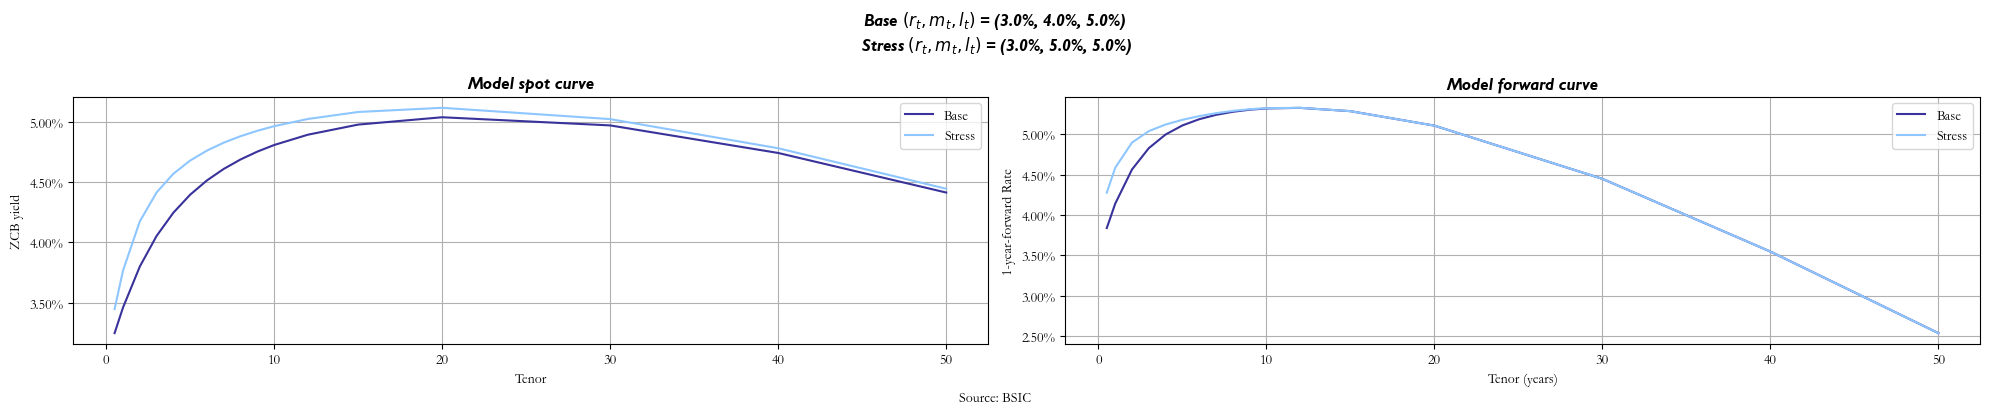

<Figure size 640x480 with 0 Axes>

In [46]:
stressEffects = {key: 0 for key in baseParams.keys()}
stressFactors = [baseFactors[0] + 0.0,
                 baseFactors[1] + 0.01,
                 baseFactors[2] + 0.0]

plotStressScenario(baseParams, stressEffects, baseFactors, stressFactors, 
                   showStressed= True, 
                   subplotTitles = ['Model spot curve', 'Model forward curve'], 
                   overallTitle=f'Base $(r_t, m_t, l_t)$ = ({baseFactors[0]:.1%}, {baseFactors[1]:.1%}, {baseFactors[2]:.1%}) \n Stress $(r_t, m_t, l_t)$ = ({stressFactors[0]:.1%}, {stressFactors[1]:.1%}, {stressFactors[2]:.1%})', 
                   figsize = (20, 4), 
                   rect = [0, 0, 1, 1.005],
                   export = True, exportName = 'pricing/pricer test pictures/shift in m_t up')

#### 1.3. Stress $l_t$

fonts already added so will not add again


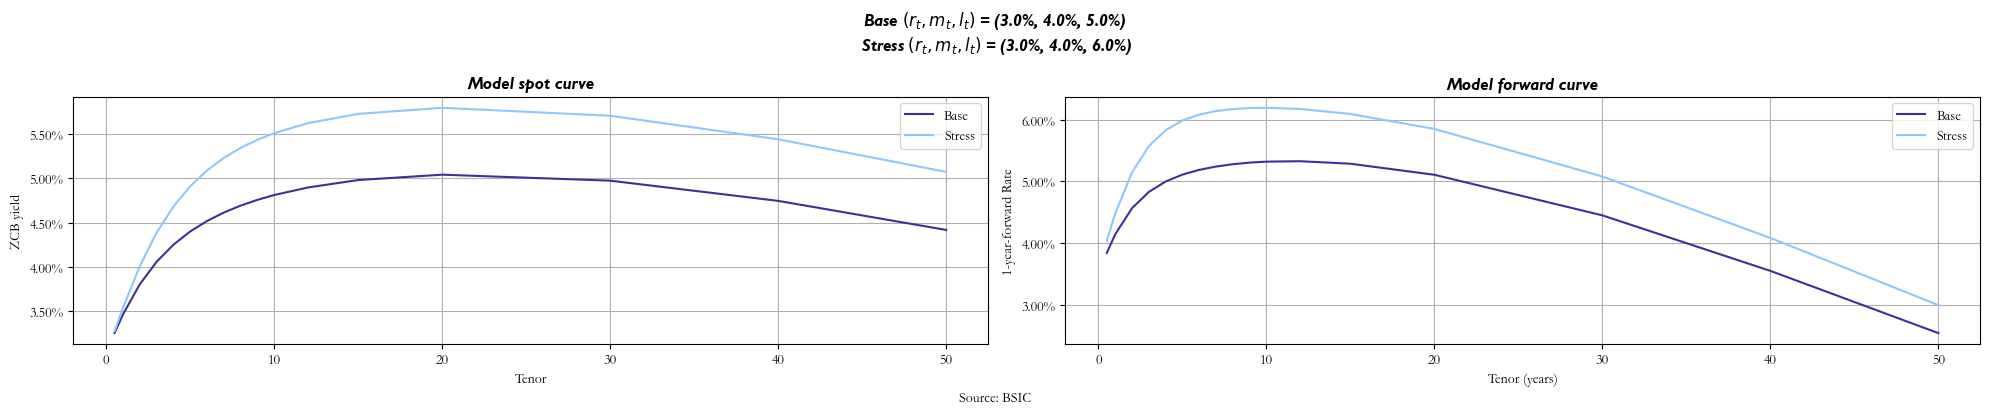

<Figure size 640x480 with 0 Axes>

In [47]:
stressEffects = {key: 0 for key in baseParams.keys()}
stressFactors = [baseFactors[0] + 0.0,
                 baseFactors[1] + 0.0,
                 baseFactors[2] + 0.01]

plotStressScenario(baseParams, stressEffects, baseFactors, stressFactors, 
                   showStressed= True, 
                   subplotTitles = ['Model spot curve', 'Model forward curve'], 
                   overallTitle=f'Base $(r_t, m_t, l_t)$ = ({baseFactors[0]:.1%}, {baseFactors[1]:.1%}, {baseFactors[2]:.1%}) \n Stress $(r_t, m_t, l_t)$ = ({stressFactors[0]:.1%}, {stressFactors[1]:.1%}, {stressFactors[2]:.1%})', 
                   figsize = (20, 4), 
                   rect = [0, 0, 1, 1.005],
                   export = True, exportName = 'pricing/pricer test pictures/shift in l_t up')

#### 1.4. Show different ($r_t, m_t, l_t$)

fonts already added so will not add again


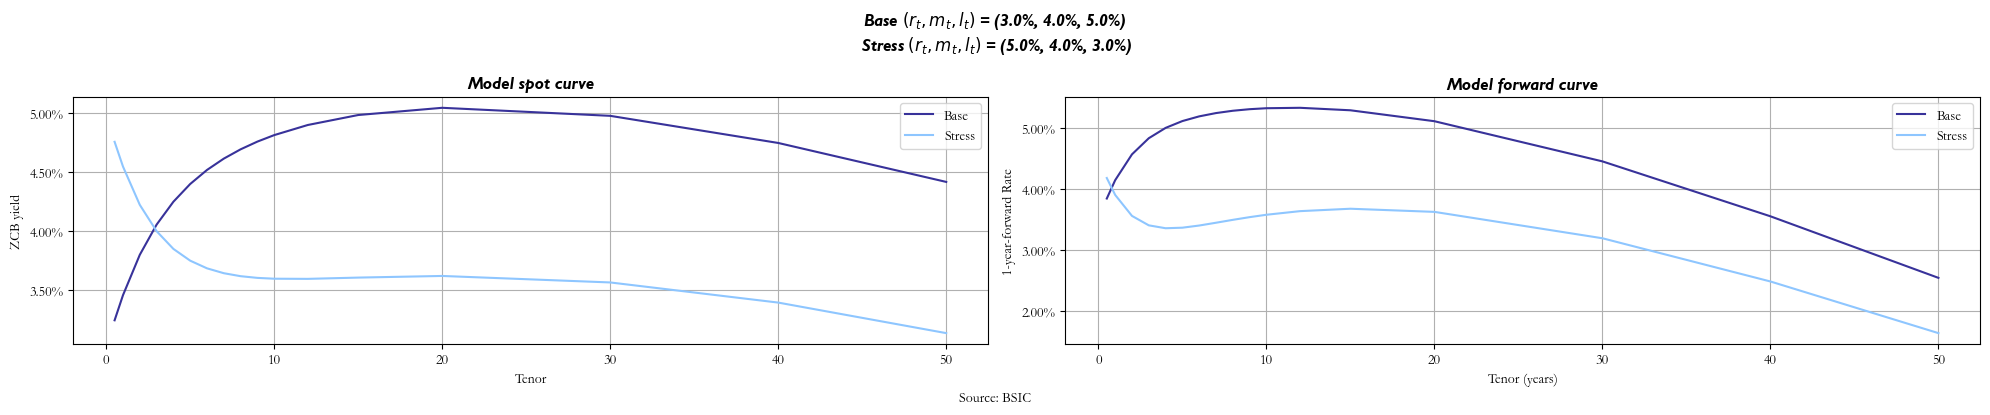

<Figure size 640x480 with 0 Axes>

In [48]:
stressEffects = {key: 0 for key in baseParams.keys()}
stressFactors = [baseFactors[0] + 0.02,
                 baseFactors[1] + 0,
                 baseFactors[2] - 0.02]

plotStressScenario(baseParams, stressEffects, baseFactors, stressFactors, 
                   showStressed= True, 
                   subplotTitles = ['Model spot curve', 'Model forward curve'], 
                   overallTitle=f'Base $(r_t, m_t, l_t)$ = ({baseFactors[0]:.1%}, {baseFactors[1]:.1%}, {baseFactors[2]:.1%}) \n Stress $(r_t, m_t, l_t)$ = ({stressFactors[0]:.1%}, {stressFactors[1]:.1%}, {stressFactors[2]:.1%})', 
                   figsize = (20, 4), 
                   rect = [0, 0, 1, 1.005],
                   export = True, exportName = 'pricing/pricer test pictures/downward sloping curve')

fonts already added so will not add again


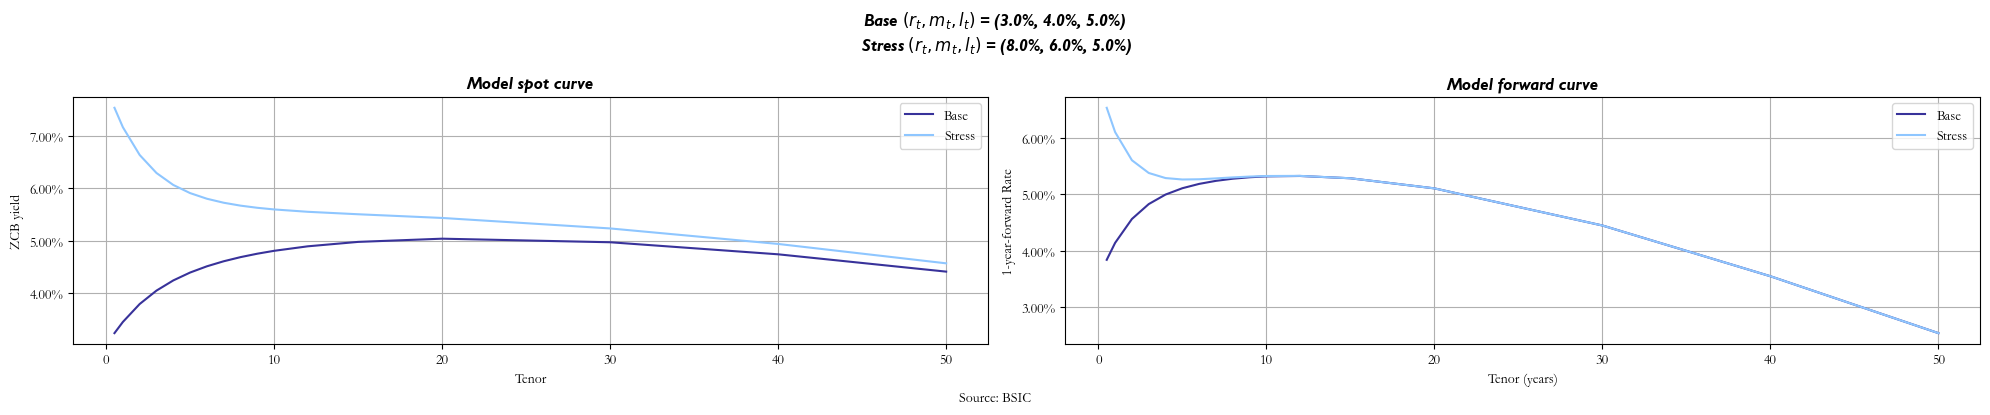

<Figure size 640x480 with 0 Axes>

In [49]:
stressEffects = {key: 0 for key in baseParams.keys()}
stressFactors = [baseFactors[0] + 0.05,
                 baseFactors[1] + 0.02,
                 baseFactors[2] + 0.0]

plotStressScenario(baseParams, stressEffects, baseFactors, stressFactors, 
                   showStressed= True, 
                   subplotTitles = ['Model spot curve', 'Model forward curve'], 
                   overallTitle=f'Base $(r_t, m_t, l_t)$ = ({baseFactors[0]:.1%}, {baseFactors[1]:.1%}, {baseFactors[2]:.1%}) \n Stress $(r_t, m_t, l_t)$ = ({stressFactors[0]:.1%}, {stressFactors[1]:.1%}, {stressFactors[2]:.1%})', 
                   figsize = (20, 4), 
                   rect = [0, 0, 1, 1.005],
                   export = True, exportName = 'pricing/pricer test pictures/downward sloping curve with higher levels')

### 2. Plots with different $(\alpha, \sigma, \mu)$

#### 2.1. Stress $\alpha$

fonts already added so will not add again


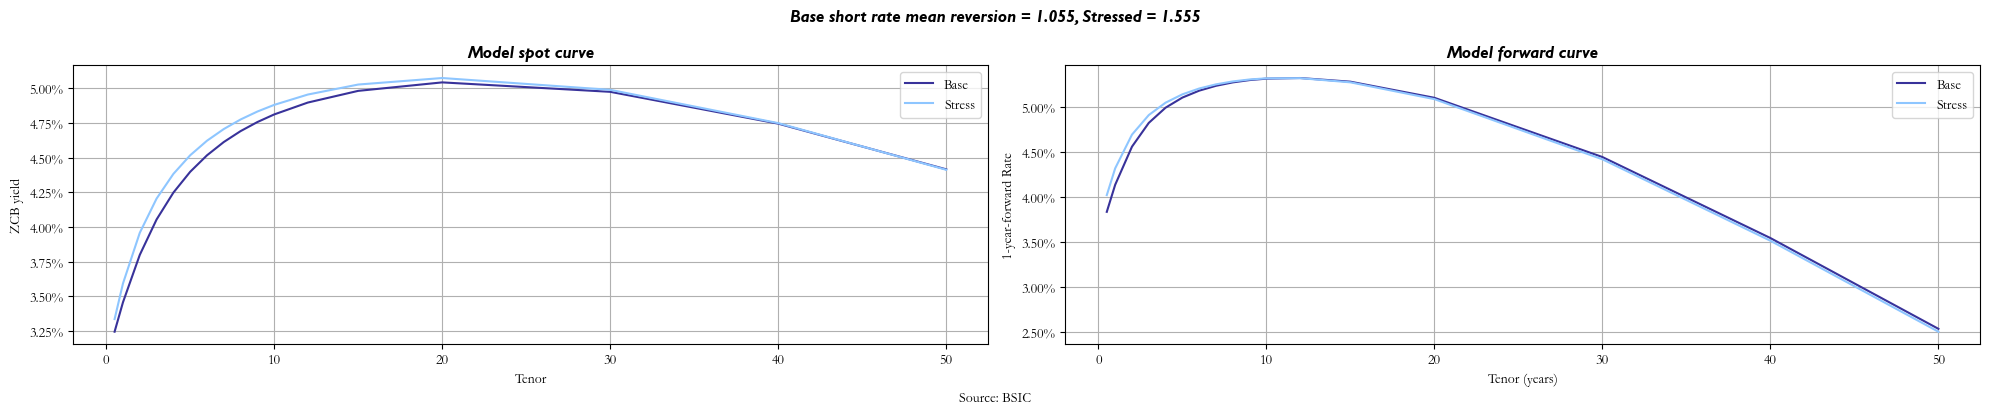

<Figure size 640x480 with 0 Axes>

In [50]:
stressEffects = {key: 0 for key in baseParams.keys()}
stressEffects['alpha_r'] = +0.5

plotStressScenario(baseParams=baseParams, stressEffects=stressEffects, baseFactors=baseFactors, stressFactors=baseFactors, 
                   showStressed=True, 
                   subplotTitles = ['Model spot curve', 'Model forward curve'], 
                   overallTitle=f'Base short rate mean reversion = {baseParams["alpha_r"]:.3f}, Stressed = {baseParams["alpha_r"] + stressEffects["alpha_r"]:.3f}', 
                   figsize = (20, 4), 
                   rect = [0, 0, 1, 1.005],
                   export = True, exportName = 'pricing/pricer test pictures/shift in alpha_r up')

fonts already added so will not add again


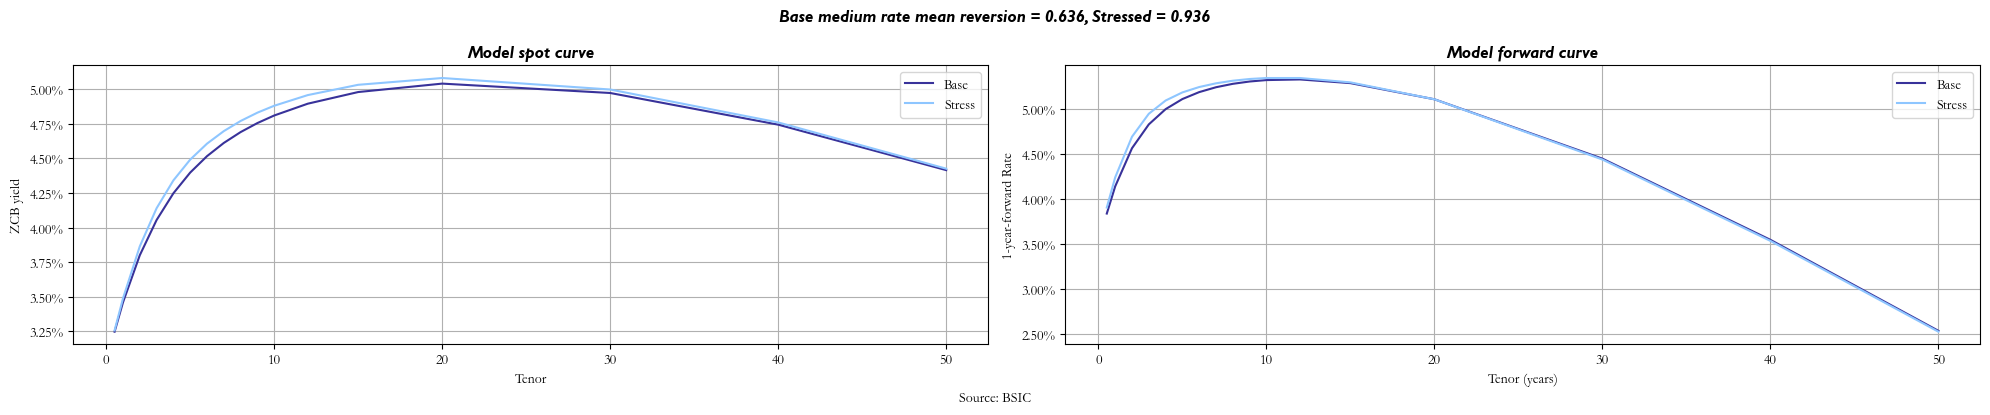

<Figure size 640x480 with 0 Axes>

In [51]:
stressEffects = {key: 0 for key in baseParams.keys()}
stressEffects['alpha_m'] = +0.3

plotStressScenario(baseParams=baseParams, stressEffects=stressEffects, baseFactors=baseFactors, stressFactors=baseFactors, 
                   showStressed=True, 
                   subplotTitles = ['Model spot curve', 'Model forward curve'], 
                   overallTitle=f'Base medium rate mean reversion = {baseParams["alpha_m"]:.3f}, Stressed = {baseParams["alpha_m"] + stressEffects["alpha_m"]:.3f}', 
                   figsize = (20, 4), 
                   rect = [0, 0, 1, 1.005],
                   export = True, exportName = 'pricing/pricer test pictures/shift in alpha_m up')

fonts already added so will not add again


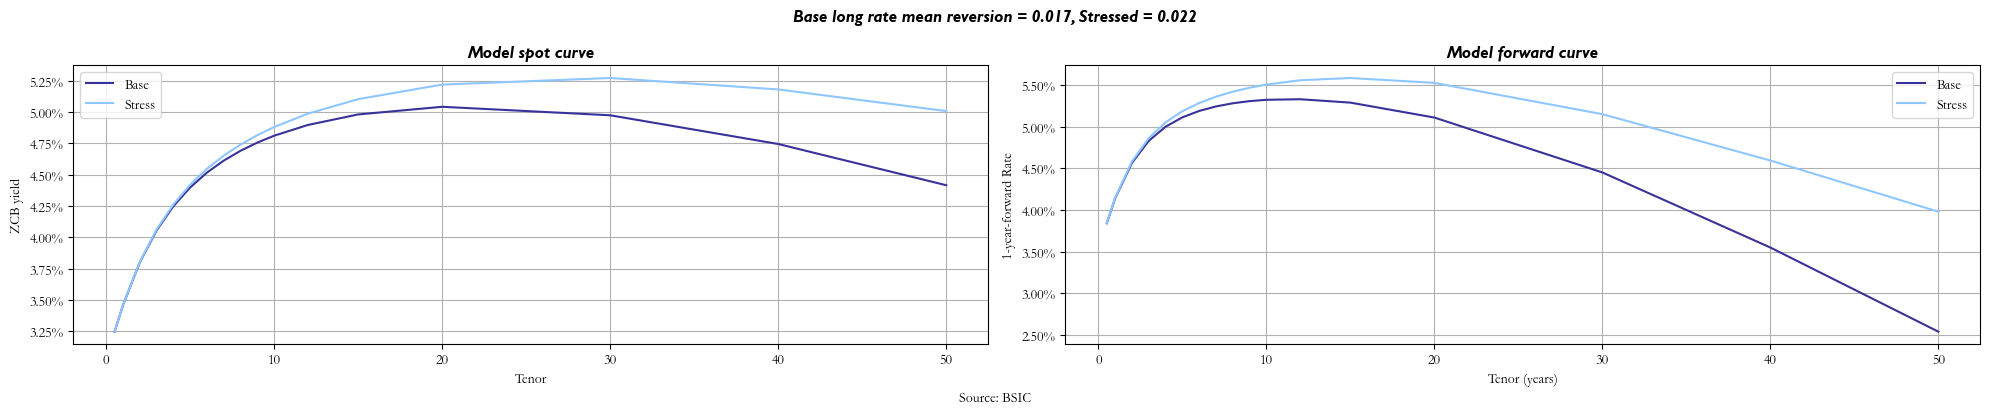

<Figure size 640x480 with 0 Axes>

In [52]:
stressEffects = {key: 0 for key in baseParams.keys()}
stressEffects['alpha_l'] = +0.005

plotStressScenario(baseParams=baseParams, stressEffects=stressEffects, baseFactors=baseFactors, stressFactors=baseFactors, 
                   showStressed=True, 
                   subplotTitles = ['Model spot curve', 'Model forward curve'], 
                   overallTitle=f'Base long rate mean reversion = {baseParams["alpha_l"]:.3f}, Stressed = {baseParams["alpha_l"] + stressEffects["alpha_l"]:.3f}', 
                   figsize = (20, 4), 
                   rect = [0, 0, 1, 1.005],
                   export = True, exportName = 'pricing/pricer test pictures/shift in alpha_l up')

#### 2.2. Stress $\sigma$

fonts already added so will not add again


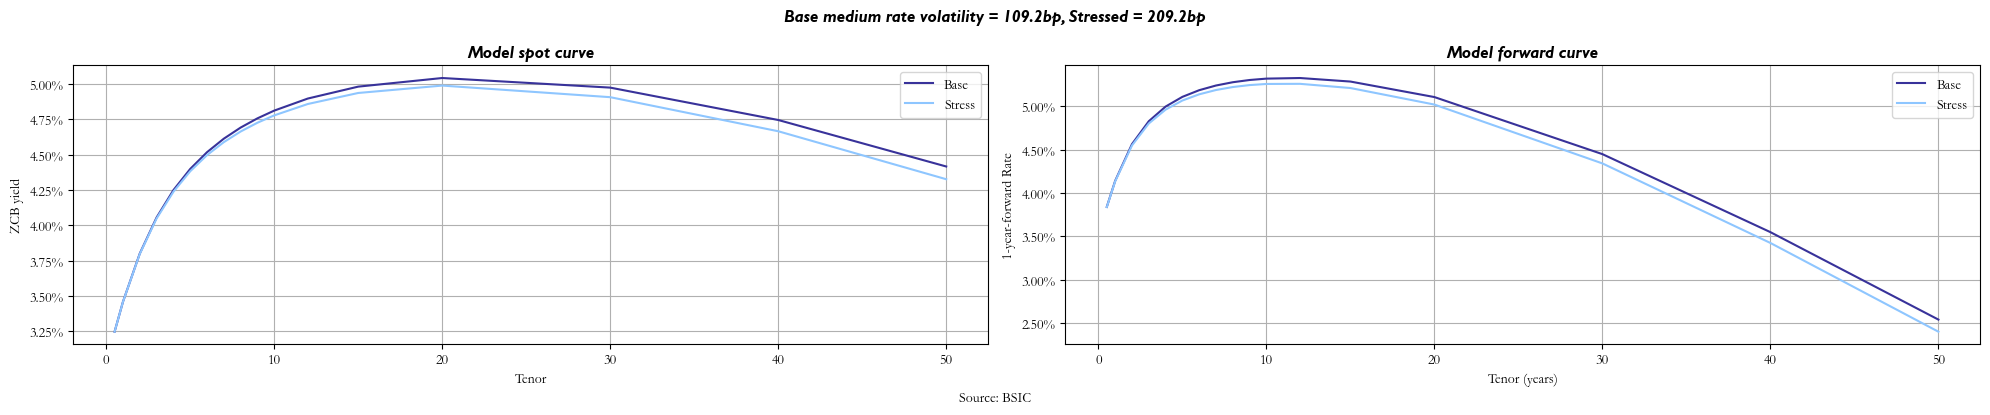

<Figure size 640x480 with 0 Axes>

In [53]:
stressEffects = {key: 0 for key in baseParams.keys()}
stressEffects['sigma_m'] = 0.01

plotStressScenario(baseParams=baseParams, stressEffects=stressEffects, baseFactors=baseFactors, stressFactors=baseFactors, 
                   showStressed=True, 
                   subplotTitles = ['Model spot curve', 'Model forward curve'], 
                   overallTitle=f'Base medium rate volatility = {baseParams["sigma_m"]*10000:.1f}bp, Stressed = {baseParams["sigma_m"]*10000 + stressEffects["sigma_m"]*10000:.1f}bp', 
                   figsize = (20, 4), 
                   rect = [0, 0, 1, 1.005],
                   export = True, exportName = 'pricing/pricer test pictures/shift in sigma_m up')

fonts already added so will not add again


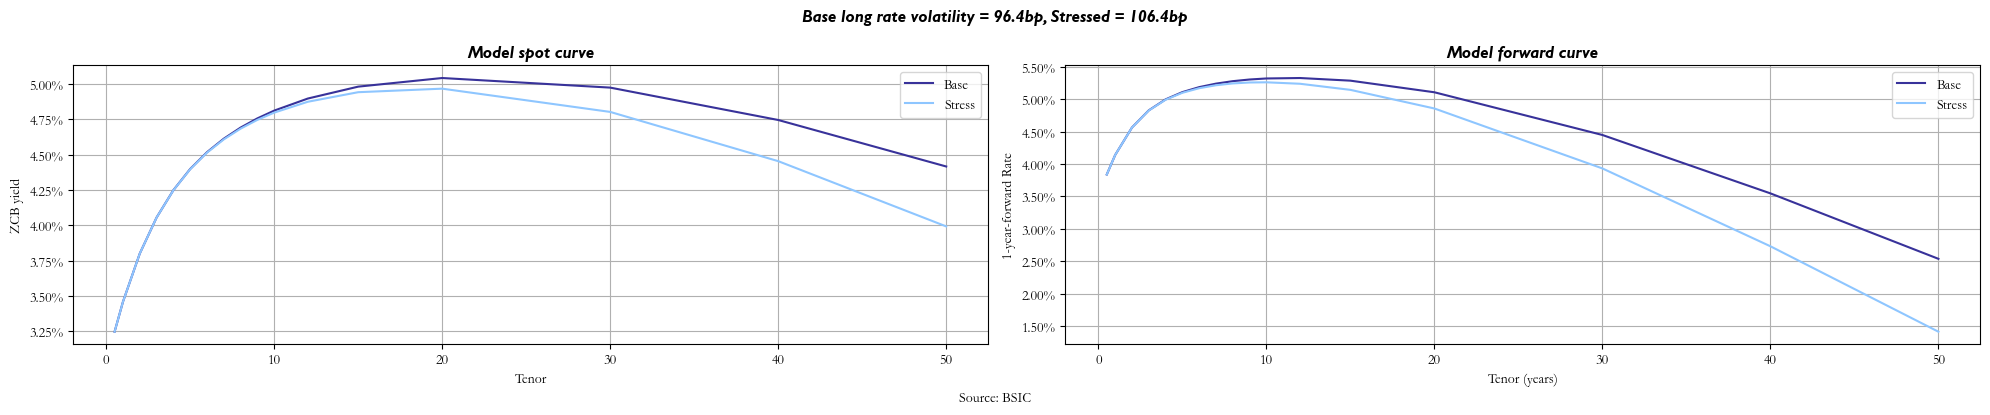

<Figure size 640x480 with 0 Axes>

In [54]:
stressEffects = {key: 0 for key in baseParams.keys()}
stressEffects['sigma_l'] = 0.001

plotStressScenario(baseParams=baseParams, stressEffects=stressEffects, baseFactors=baseFactors, stressFactors=baseFactors, 
                   showStressed=True, 
                   subplotTitles = ['Model spot curve', 'Model forward curve'], 
                   overallTitle=f'Base long rate volatility = {baseParams["sigma_l"]*10000:.1f}bp, Stressed = {baseParams["sigma_l"]*10000 + stressEffects["sigma_l"]*10000:.1f}bp', 
                   figsize = (20, 4), 
                   rect = [0, 0, 1, 1.005],
                   export = True, exportName = 'pricing/pricer test pictures/shift in sigma_l up')

fonts already added so will not add again


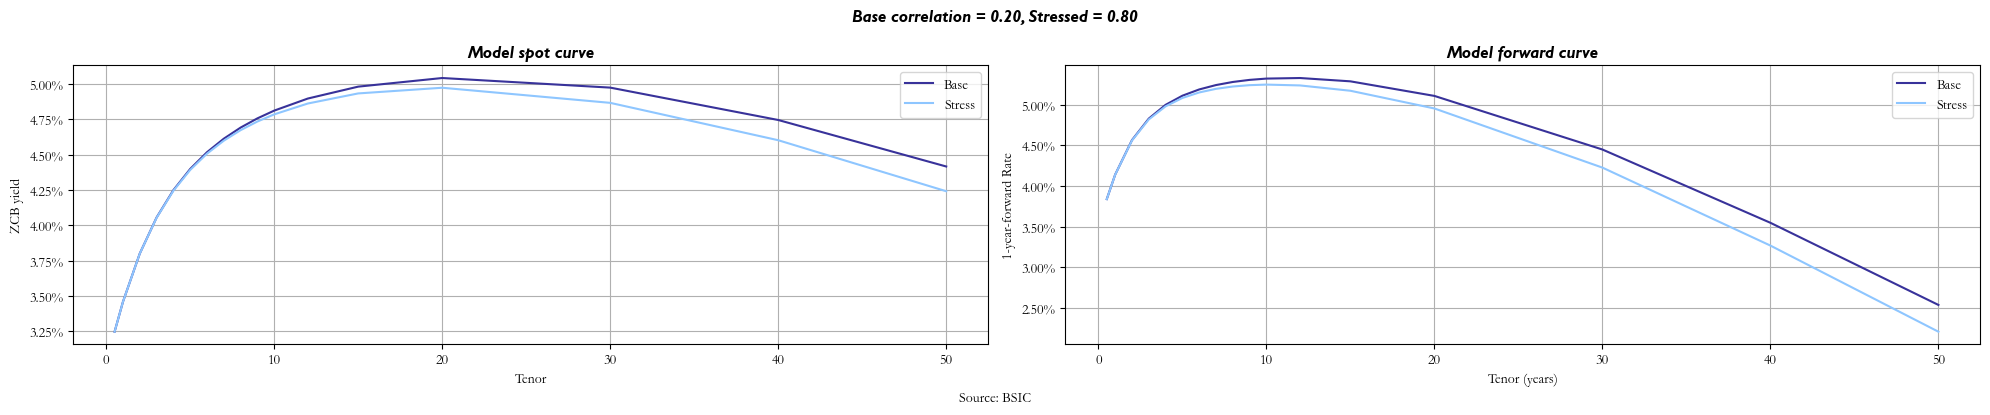

<Figure size 640x480 with 0 Axes>

In [55]:
stressEffects = {key: 0 for key in baseParams.keys()}
stressEffects['rho'] = 0.6

plotStressScenario(baseParams=baseParams, stressEffects=stressEffects, baseFactors=baseFactors, stressFactors=baseFactors, 
                   showStressed=True, 
                   subplotTitles = ['Model spot curve', 'Model forward curve'], 
                   overallTitle=f'Base correlation = {baseParams["rho"]:.2f}, Stressed = {baseParams["rho"] + stressEffects["rho"]:.2f}', 
                   figsize = (20, 4), 
                   rect = [0, 0, 1, 1.005],
                   export = True, exportName = 'pricing/pricer test pictures/shift in rho up')

#### 2.3. Stress $\mu$

fonts already added so will not add again


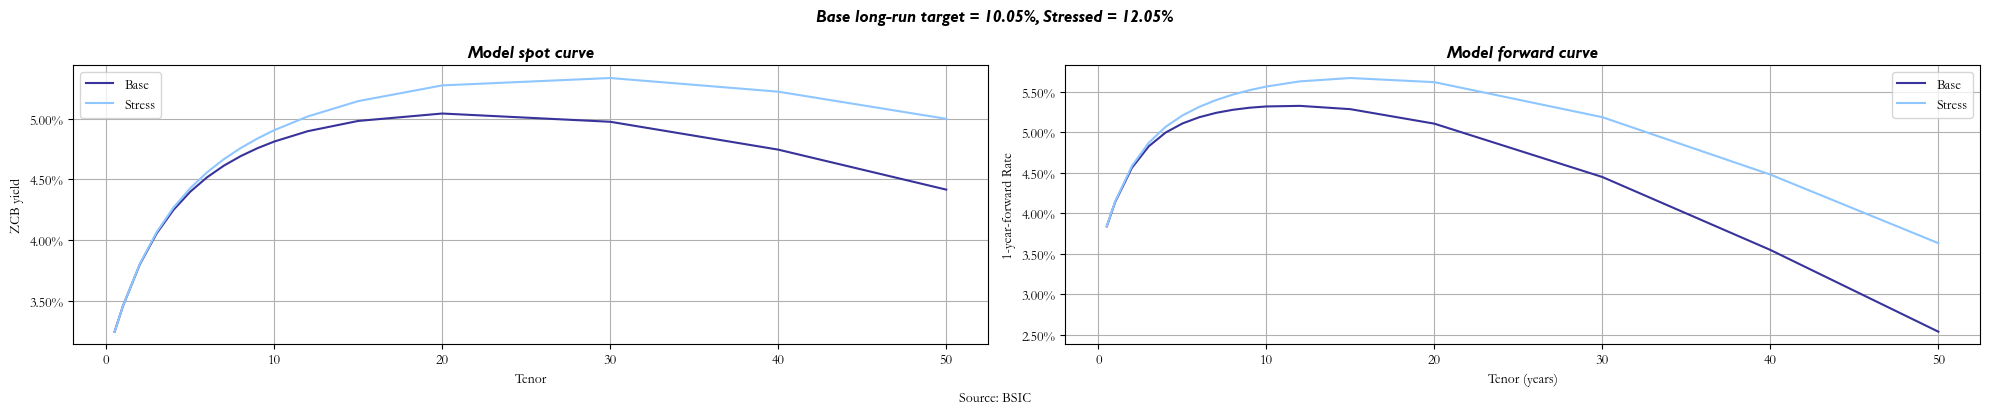

<Figure size 640x480 with 0 Axes>

In [56]:
stressEffects = {key: 0 for key in baseParams.keys()}
stressEffects['mu'] = +0.02

plotStressScenario(baseParams=baseParams, stressEffects=stressEffects, baseFactors=baseFactors, stressFactors=baseFactors, 
                   showStressed=True, 
                   subplotTitles = ['Model spot curve', 'Model forward curve'], 
                   overallTitle=f'Base long-run target = {baseParams["mu"]:.2%}, Stressed = {baseParams["mu"] + stressEffects["mu"]:.2%}', 
                   figsize = (20, 4), 
                   rect = [0, 0, 1, 1.005],
                   export = True, exportName = 'pricing/pricer test pictures/shift in mu up')